In [32]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize


# Data directory
base_path = "/Users/gracie/Desktop/DATA/DATA 300/Project"


### DATA CLEANING ###

In [2]:
# Load all data
dfs = []

# Loop through years and months
for year in range(2020, 2026):  # 2020–2025
    for month in range(1, 13):  # Jan–Dec
        
        file_path = f"{base_path}/{year}/T_ONTIME_REPORTING-{month}.csv"
        
        if os.path.exists(file_path):  # safety check
            df_temp = pd.read_csv(file_path)
            
            # Add year + month explicitly
            df_temp["YEAR"] = year
            df_temp["MONTH"] = month
            
            dfs.append(df_temp)
        else:
            print(f"Missing file: {file_path}")

# Combine everything into one dataframe
df = pd.concat(dfs, ignore_index=True)

/var/folders/91/4d0_7f2176gdgm2kh89mg4s40000gn/T/ipykernel_75059/4119370907.py:11: DtypeWarning: Columns (0: CANCELLATION_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path)
/var/folders/91/4d0_7f2176gdgm2kh89mg4s40000gn/T/ipykernel_75059/4119370907.py:11: DtypeWarning: Columns (0: CANCELLATION_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path)
/var/folders/91/4d0_7f2176gdgm2kh89mg4s40000gn/T/ipykernel_75059/4119370907.py:11: DtypeWarning: Columns (0: CANCELLATION_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path)
/var/folders/91/4d0_7f2176gdgm2kh89mg4s40000gn/T/ipykernel_75059/4119370907.py:11: DtypeWarning: Columns (0: CANCELLATION_CODE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file_path)
/var/folders/91/4d0_7f2176gdgm2kh89mg4s40000gn/T/ipy

In [3]:
# 2. Cleaning

# Keep only MDT flights
df = df[df["ORIGIN"] == "MDT"]

# Remove cancelled flights
df = df[df["CANCELLED"] == 0]

# Drop missing target
df = df.dropna(subset=["ARR_DEL15"])

# Keep only needed columns
df = df[[
    "YEAR",
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "OP_UNIQUE_CARRIER",
    "DEST",
    "DISTANCE",
    "CRS_ELAPSED_TIME",
    "TAIL_NUM",
    "FL_DATE",
    "ARR_DEL15",
    "ARR_DELAY_NEW"
]]

# Convert types
df["ARR_DEL15"] = df["ARR_DEL15"].astype(int)
df["ARR_DELAY_NEW"] = df["ARR_DELAY_NEW"].astype(int)
df["DISTANCE"] = pd.to_numeric(df["DISTANCE"], errors="coerce")
df["CRS_DEP_TIME"] = pd.to_numeric(df["CRS_DEP_TIME"], errors="coerce")
df["CRS_ELAPSED_TIME"] = pd.to_numeric(df["CRS_ELAPSED_TIME"], errors="coerce")

# Drop any remaining missing values
df = df.dropna()

# Create usable time feature (replaces raw CRS_DEP_TIME)
df["DEP_HOUR"] = df["CRS_DEP_TIME"] // 100


In [4]:
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'], format='%m/%d/%Y %I:%M:%S %p')
# Ensure data is ordered so 'previous' actually means 'earlier that day'
df = df.sort_values(['TAIL_NUM', 'FL_DATE', 'CRS_DEP_TIME'], ascending=[True, True, True])

# Identify if the plane was late on its previous leg
# We use 'ARR_DEL15' from the previous row (shift)
df['PREV_FLIGHT_DELAYED'] = df.groupby(['TAIL_NUM', 'FL_DATE'])['ARR_DEL15'].shift(1)

# Fill NaN (the first flight of the day for a plane has no "previous" flight)
df['PREV_FLIGHT_DELAYED'] = df['PREV_FLIGHT_DELAYED'].fillna(0)

df['PREV_FLIGHT_DELAYED'] = df['PREV_FLIGHT_DELAYED'].astype(int)

In [5]:
# Cap extreme outliers before clustering (flights delayed >300 min are rare errors)
delay_cap = df["ARR_DELAY_NEW"].quantile(0.99)
print(f"Capping delays above: {delay_cap:.0f} minutes")
df["ARR_DELAY_CAPPED"] = df["ARR_DELAY_NEW"].clip(upper=delay_cap)

# Only cluster on flights that actually had a delay (>0 mins)
# We'll assign on-time flights cluster 0 separately
delayed = df[df["ARR_DELAY_CAPPED"] > 0][["ARR_DELAY_CAPPED"]].copy()

# Fit KMeans on delayed flights to find natural delay severity groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(delayed[["ARR_DELAY_CAPPED"]])

# Check what boundaries it found
centers = sorted(kmeans.cluster_centers_.flatten())
print("Cluster centers (minutes):", centers)

# Assign clusters back — label by severity (0=least, 1=mid, 2=worst)
delayed["RAW_CLUSTER"] = kmeans.labels_
center_order = np.argsort(kmeans.cluster_centers_.flatten())
remap = {old: new for new, old in enumerate(center_order)}
delayed["DELAY_CLUSTER"] = delayed["RAW_CLUSTER"].map(remap)

# Now assign to full df:
# On-time flights (ARR_DELAY_NEW == 0) → class 0
# Delayed flights get cluster + 1 (so clusters become 1, 2, 3)
df["DELAY_CLUSTER"] = 0
df.loc[delayed.index, "DELAY_CLUSTER"] = delayed["DELAY_CLUSTER"] + 1

print("\nDelay cluster distribution:")
print(df["DELAY_CLUSTER"].value_counts().sort_index())
print("\nMeaning: 0=On-time, 1=Minor delay, 2=Moderate delay, 3=Severe delay")

Capping delays above: 243 minutes
Cluster centers (minutes): [15.535264674655256, 85.88835244417612, 213.96385542168667]

Delay cluster distribution:
DELAY_CLUSTER
0    20367
1     6593
2     1657
3      664
Name: count, dtype: int64

Meaning: 0=On-time, 1=Minor delay, 2=Moderate delay, 3=Severe delay


In [6]:
df.to_csv(f"{base_path}/cleaned_flight_data.csv", index=False)

### EXPLORATORY DATA ANALYSIS ###

In [7]:
# Data overview
df.shape
df.info()

<class 'pandas.DataFrame'>
Index: 29281 entries, 1087201 to 809569
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   YEAR                 29281 non-null  int64         
 1   MONTH                29281 non-null  int64         
 2   DAY_OF_MONTH         29281 non-null  int64         
 3   DAY_OF_WEEK          29281 non-null  int64         
 4   CRS_DEP_TIME         29281 non-null  int64         
 5   OP_UNIQUE_CARRIER    29281 non-null  str           
 6   DEST                 29281 non-null  str           
 7   DISTANCE             29281 non-null  float64       
 8   CRS_ELAPSED_TIME     29281 non-null  float64       
 9   TAIL_NUM             29281 non-null  str           
 10  FL_DATE              29281 non-null  datetime64[us]
 11  ARR_DEL15            29281 non-null  int64         
 12  ARR_DELAY_NEW        29281 non-null  int64         
 13  DEP_HOUR             29281 non-null  int

In [8]:
df.head()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,OP_UNIQUE_CARRIER,DEST,DISTANCE,CRS_ELAPSED_TIME,TAIL_NUM,FL_DATE,ARR_DEL15,ARR_DELAY_NEW,DEP_HOUR,PREV_FLIGHT_DELAYED,ARR_DELAY_CAPPED,DELAY_CLUSTER
1087201,2024,2,19,1,1957,G4,FLL,993.0,177.0,188NV,2024-02-19,1,209,19,0,209,3
1145294,2024,5,2,4,1536,G4,MYR,465.0,86.0,188NV,2024-05-02,0,3,15,0,3,1
1145295,2024,5,2,4,2017,G4,SFB,827.0,138.0,188NV,2024-05-02,0,0,20,0,0,0
1146148,2024,5,3,5,1642,G4,SFB,827.0,138.0,188NV,2024-05-03,0,0,16,0,0,0
1147800,2024,5,5,7,1536,G4,MYR,465.0,86.0,188NV,2024-05-05,0,12,15,0,12,1


In [9]:
# Summary statistics
df.describe()

,YEAR,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,DISTANCE,CRS_ELAPSED_TIME,FL_DATE,ARR_DEL15,ARR_DELAY_NEW,DEP_HOUR,PREV_FLIGHT_DELAYED,ARR_DELAY_CAPPED,DELAY_CLUSTER
count,29281.000000,29281.000000,29281.000000,29281.000000,29281.000000,29281.000000,29281.000000,29281,29281.000000,29281.000000,29281.000000,29281.000000,29281.000000,29281.000000
mean,2022.645060,6.660394,15.735289,4.043031,1202.140193,611.599672,126.417609,2023-02-26 19:53:30.996892,0.173935,15.799221,11.771763,0.004508,13.210375,0.406373
min,2020.000000,1.000000,1.000000,1.000000,500.000000,84.000000,47.000000,2020-01-01 00:00:00,0.000000,0.000000,5.000000,0.000000,0.000000,0.000000
25%,2021.000000,4.000000,8.000000,2.000000,650.000000,413.000000,102.000000,2021-10-10 00:00:00,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000
50%,2023.000000,7.000000,16.000000,4.000000,1213.000000,594.000000,124.000000,2023-03-27 00:00:00,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000
75%,2024.000000,10.000000,23.000000,6.000000,1707.000000,620.000000,138.000000,2024-07-26 00:00:00,0.000000,5.000000,17.000000,0.000000,5.000000,1.000000
max,2025.000000,12.000000,31.000000,7.000000,2250.000000,2369.000000,358.000000,2025-12-31 00:00:00,1.000000,3337.000000,22.000000,1.000000,243.000000,3.000000
std,1.640756,3.400272,8.746727,2.016105,488.809464,251.066385,32.767897,NaN,0.379060,67.245308,4.839916,0.066992,37.911593,0.700350


In [10]:
# Class balance
df["DELAY_CLUSTER"].value_counts()
df["DELAY_CLUSTER"].value_counts(normalize=True).round(3)

DELAY_CLUSTER
0    0.696
1    0.225
2    0.057
3    0.023
Name: proportion, dtype: float64

In [11]:
# Airline distribution
df["OP_UNIQUE_CARRIER"].value_counts()

OP_UNIQUE_CARRIER
G4    4843
OH    4000
AA    3988
OO    3800
DL    3708
9E    3184
MQ    1987
UA    1557
YX    1520
F9     687
YV       7
Name: count, dtype: int64

In [12]:
# Destination distribution
df["DEST"].value_counts()

DEST
CLT    6303
ORD    5601
ATL    5349
DTW    3713
DFW    2017
SFB    1563
PIE     825
PGD     758
EWR     660
MCO     632
SRQ     557
BNA     459
MYR     299
FLL     243
JAX     139
PHL      84
DEN      55
MIA      11
IAD       7
MSP       2
EUG       1
SEA       1
PHX       1
LAX       1
Name: count, dtype: int64

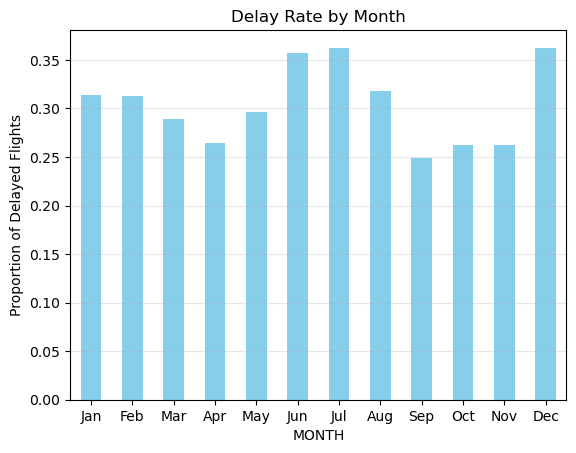

In [13]:
# Delay rate by month
monthly = df.groupby("MONTH")["DELAY_CLUSTER"].apply(lambda x: (x > 0).mean())

monthly.plot(kind="bar", color="skyblue")
plt.title("Delay Rate by Month")
plt.ylabel("Proportion of Delayed Flights")
plt.xticks(ticks=range(12), labels=[
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

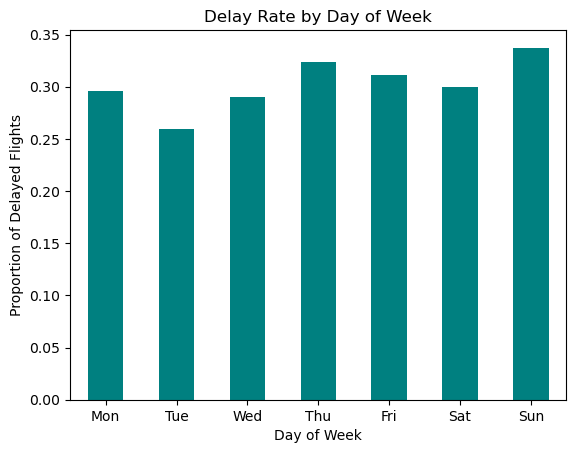

In [14]:
# Delay rate by day of week
dow_rate = df.groupby("DAY_OF_WEEK")["DELAY_CLUSTER"].apply(lambda x: (x > 0).mean())
dow_rate.plot(kind="bar", color="teal")
plt.title("Delay Rate by Day of Week")
plt.xticks(ticks=range(7), labels=[
    "Mon","Tue","Wed","Thu","Fri","Sat","Sun"
])
plt.xticks(rotation=0)
plt.xlabel("Day of Week")
plt.ylabel("Proportion of Delayed Flights")
plt.show()

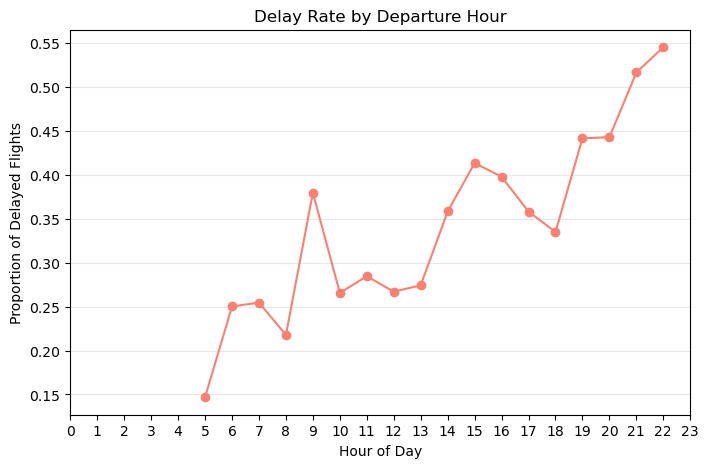

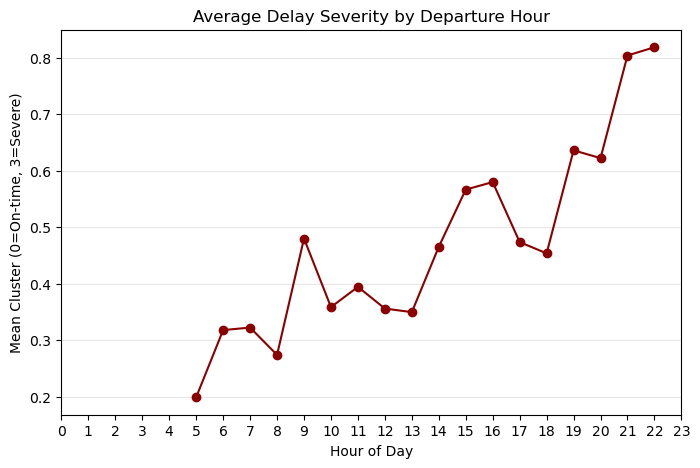

In [15]:
# Delay rate by departure hour
hourly_delay = df.groupby("DEP_HOUR")["DELAY_CLUSTER"].apply(lambda x: (x > 0).mean())

plt.figure(figsize=(8,5))
plt.plot(hourly_delay.index, hourly_delay.values, marker='o', color='salmon')
plt.title("Delay Rate by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Proportion of Delayed Flights")
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()

# Average severity by hour
hourly_severity = df.groupby("DEP_HOUR")["DELAY_CLUSTER"].mean()
plt.figure(figsize=(8,5))
plt.plot(hourly_severity.index, hourly_severity.values, marker='o', color='darkred')
plt.title("Average Delay Severity by Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Mean Cluster (0=On-time, 3=Severe)")
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.show()

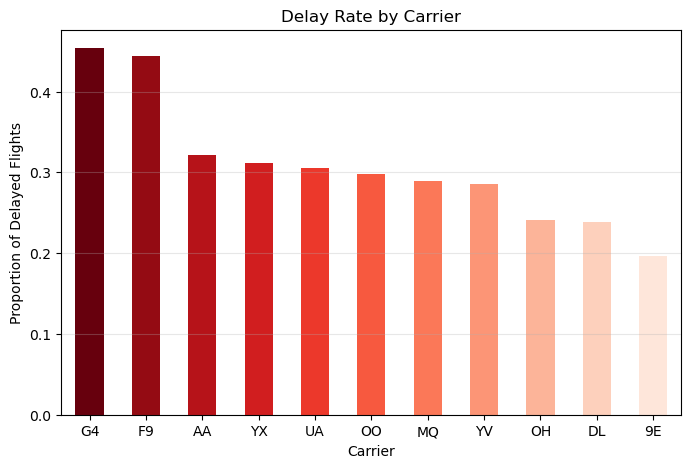

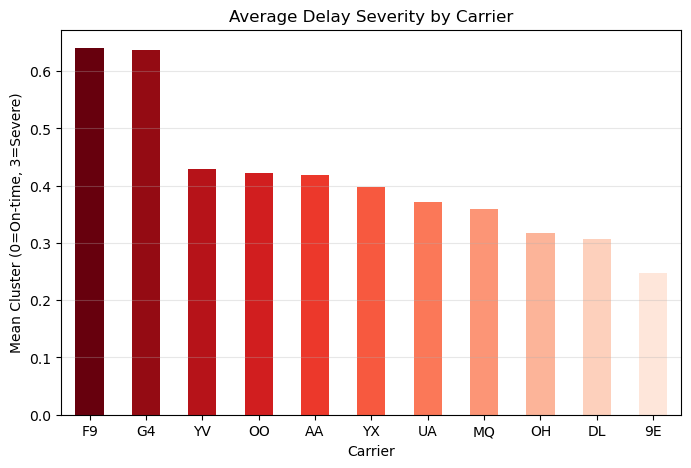

In [16]:
carrier_col = "OP_UNIQUE_CARRIER"

carrier_delay = (
    df.groupby(carrier_col)["DELAY_CLUSTER"]
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
carrier_delay.plot(kind="bar", color=cm.Reds(carrier_delay.rank(pct=True)))
plt.title("Delay Rate by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Proportion of Delayed Flights")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

# Average severity by carrier
carrier_severity = (
    df.groupby(carrier_col)["DELAY_CLUSTER"]
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(8,5))
carrier_severity.plot(kind="bar", color=cm.Reds(carrier_severity.rank(pct=True)))
plt.title("Average Delay Severity by Carrier")
plt.xlabel("Carrier")
plt.ylabel("Mean Cluster (0=On-time, 3=Severe)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

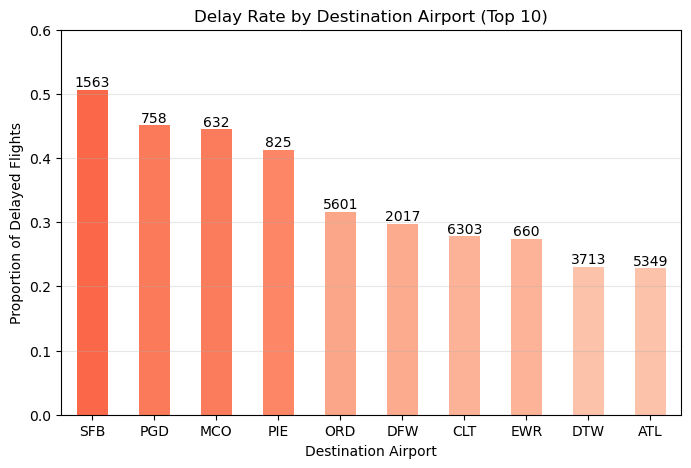

In [17]:
top_dest = df["DEST"].value_counts().head(10).index

dest_delay = (
    df[df["DEST"].isin(top_dest)]
    .groupby("DEST")["DELAY_CLUSTER"]
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
)

counts = df[df["DEST"].isin(top_dest)]["DEST"].value_counts()
counts = counts[dest_delay.index]

colors = cm.Reds(dest_delay.values)
ax = dest_delay.plot(kind="bar", figsize=(8,5), color=colors)
for i, v in enumerate(dest_delay.index):
    ax.text(i, dest_delay[v] + 0.005, str(counts[v]), ha='center')

plt.title("Delay Rate by Destination Airport (Top 10)")
plt.xlabel("Destination Airport")
plt.ylabel("Proportion of Delayed Flights")
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=0)
plt.ylim(0, 0.6)
plt.show()

In [18]:
# Proportion of each delay cluster given previous flight status
pd.crosstab(
    df['PREV_FLIGHT_DELAYED'],
    df['DELAY_CLUSTER'],
    normalize='index'
).round(3)

DELAY_CLUSTER,0,1,2,3
PREV_FLIGHT_DELAYED,,,,
0,0.698,0.224,0.056,0.022
1,0.189,0.394,0.288,0.129


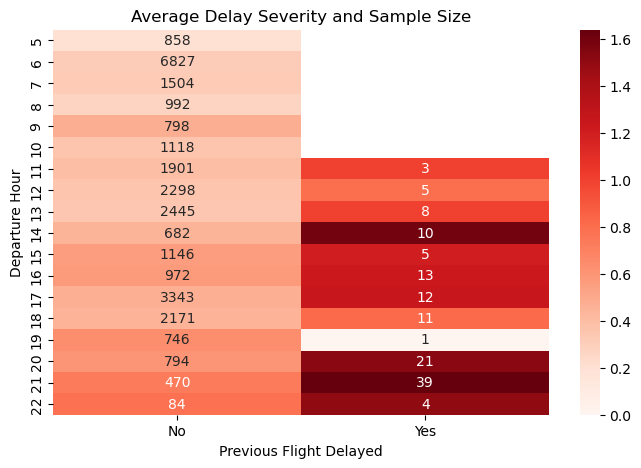

In [19]:
counts = df.groupby(['DEP_HOUR', 'PREV_FLIGHT_DELAYED']).size().unstack()
severity = df.groupby(['DEP_HOUR', 'PREV_FLIGHT_DELAYED'])['DELAY_CLUSTER'].mean().unstack()
severity.columns = ['No', 'Yes']
counts.columns = ['No', 'Yes']

plt.figure(figsize=(8,5))
sns.heatmap(severity, annot=counts, fmt=".0f", cmap="Reds")
plt.title("Average Delay Severity and Sample Size")
plt.xlabel("Previous Flight Delayed")
plt.ylabel("Departure Hour")
plt.show()

### SPLITTING DATA ###

In [20]:
X = df[[
    "MONTH",
    "DAY_OF_MONTH",
    "DAY_OF_WEEK",
    "CRS_DEP_TIME",
    "OP_UNIQUE_CARRIER",
    "DEST",
    "DISTANCE",
    "CRS_ELAPSED_TIME",
    "PREV_FLIGHT_DELAYED",
    "DEP_HOUR"
]]

y = df["DELAY_CLUSTER"]

In [21]:
X = pd.get_dummies(
    X,
    columns=["OP_UNIQUE_CARRIER", "DEST"],
    drop_first=True
)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # ensures all 4 classes are proportionally represented
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (23424, 41)
Test shape: (5857, 41)

Train class balance:
DELAY_CLUSTER
0    0.696
1    0.225
2    0.057
3    0.023
Name: proportion, dtype: float64

Test class balance:
DELAY_CLUSTER
0    0.696
1    0.225
2    0.057
3    0.023
Name: proportion, dtype: float64


### DATA PREPARATION

In [23]:
# Sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# Scaled version for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Class distribution:")
print(y_train.value_counts(normalize=True).round(3))

Class distribution:
DELAY_CLUSTER
0    0.696
1    0.225
2    0.057
3    0.023
Name: proportion, dtype: float64


### LOGISTIC REGRESSION

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

     On-time       0.00      0.00      0.00      4074
       Minor       0.00      0.00      0.00      1319
    Moderate       0.11      0.04      0.05       331
      Severe       0.02      0.98      0.04       133

    accuracy                           0.02      5857
   macro avg       0.03      0.25      0.02      5857
weighted avg       0.01      0.02      0.00      5857

Weighted F1: 0.0041


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


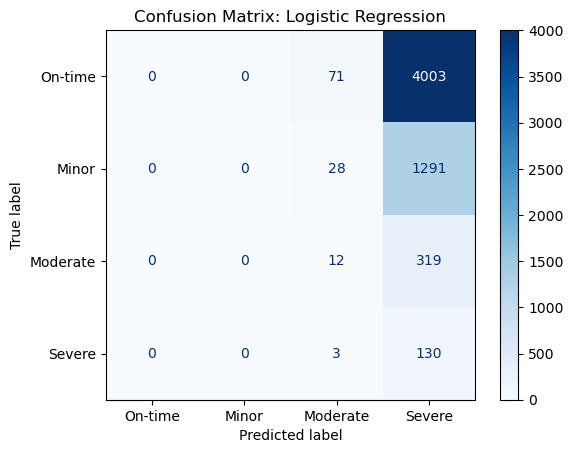

In [24]:
lr = LogisticRegression(
    multi_class='multinomial',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train, sample_weight=sample_weights)
y_pred_lr = lr.predict(X_test_scaled)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=["On-time", "Minor", "Moderate", "Severe"]))
print(f"Weighted F1: {f1_score(y_test, y_pred_lr, average='weighted'):.4f}")

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
       display_labels=["On-time", "Minor", "Moderate", "Severe"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Logistic Regression")
plt.show()

### RANDOM FOREST


Classification Report:
              precision    recall  f1-score   support

     On-time       0.77      0.77      0.77      4074
       Minor       0.35      0.32      0.33      1319
    Moderate       0.15      0.21      0.17       331
      Severe       0.05      0.05      0.05       133

    accuracy                           0.62      5857
   macro avg       0.33      0.34      0.33      5857
weighted avg       0.62      0.62      0.62      5857

Weighted F1: 0.6214


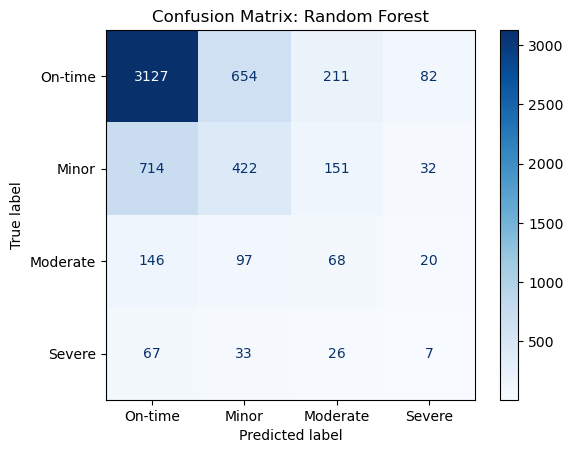

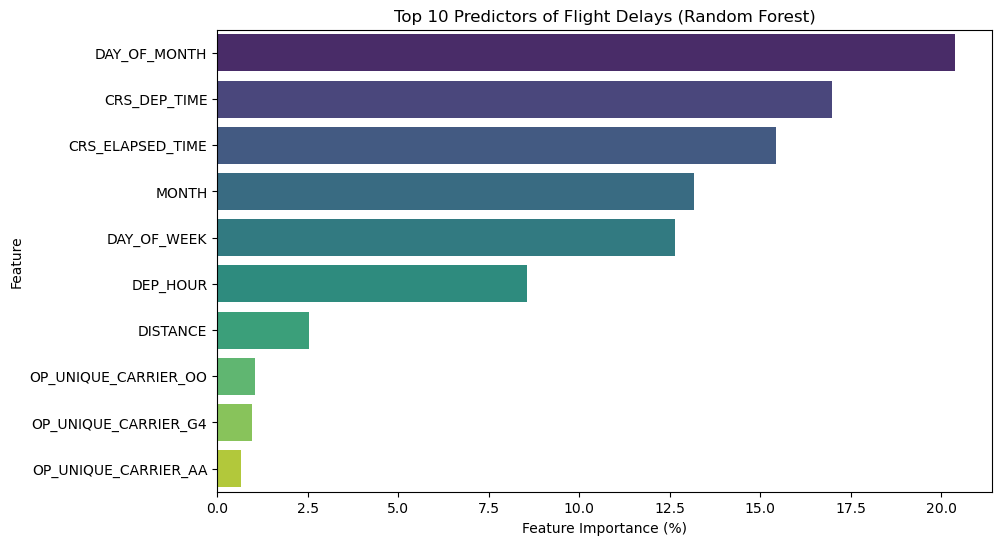

In [25]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_rf = rf.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
      target_names=["On-time", "Minor", "Moderate", "Severe"]))
print(f"Weighted F1: {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
       display_labels=["On-time", "Minor", "Moderate", "Severe"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Random Forest")
plt.show()

importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances * 100})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df,
            hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Predictors of Flight Delays (Random Forest)')
plt.xlabel('Feature Importance (%)')
plt.show()

### XGBoost

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [22:23:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report:
              precision    recall  f1-score   support

     On-time       0.71      0.97      0.82      4074
       Minor       0.42      0.09      0.15      1319
    Moderate       0.33      0.03      0.05       331
      Severe       0.00      0.00      0.00       133

    accuracy                           0.70      5857
   macro avg       0.37      0.27      0.26      5857
weighted avg       0.61      0.70      0.61      5857

Weighted F1: 0.6095


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


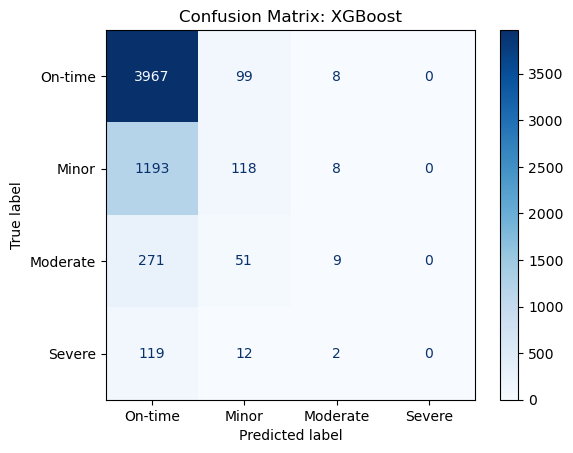

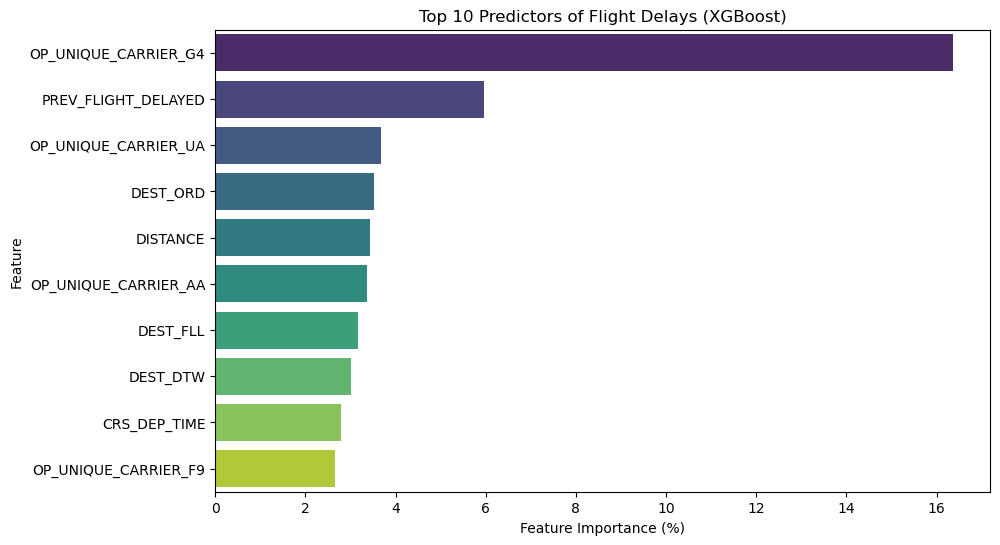

In [26]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',   # multi-class log loss
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=["On-time", "Minor", "Moderate", "Severe"]))
print(f"Weighted F1: {f1_score(y_test, y_pred_xgb, average='weighted'):.4f}")

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,
       display_labels=["On-time", "Minor", "Moderate", "Severe"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: XGBoost")
plt.show()

importances = xgb.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances * 100})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df,
            hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Predictors of Flight Delays (XGBoost)')
plt.xlabel('Feature Importance (%)')
plt.show()

### MODEL COMPARISION

                     Weighted F1  Macro F1  Accuracy
Model                                               
Logistic Regression       0.0041    0.0245    0.0242
Random Forest             0.6214    0.3319    0.6187
XGBoost                   0.6095    0.2556    0.6990


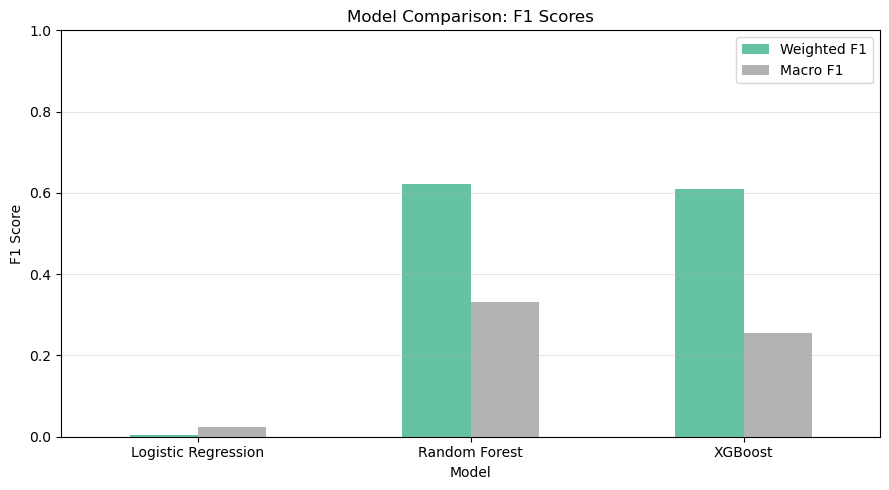

In [27]:
models = ["Logistic Regression", "Random Forest", "XGBoost"]
preds  = [y_pred_lr, y_pred_rf, y_pred_xgb]

results = []
for name, pred in zip(models, preds):
    results.append({
        "Model":       name,
        "Weighted F1": round(f1_score(y_test, pred, average='weighted'), 4),
        "Macro F1":    round(f1_score(y_test, pred, average='macro'), 4),
        "Accuracy":    round(accuracy_score(y_test, pred), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
print(results_df)

results_df[["Weighted F1", "Macro F1"]].plot(kind='bar', figsize=(9, 5), colormap='Set2')
plt.title("Model Comparison: F1 Scores")
plt.ylabel("F1 Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### DISTRIBUTION OF PREDICTED PROBABILITIES, PRECISION-RECALL TRADEOFF, ROC CURVE & PRECISION-RECALL CURVE

In [28]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

# Class names and colors for consistent styling
class_names = ["On-time", "Minor", "Moderate", "Severe"]
n_classes = 4
class_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

# Binarize y_test for one-vs-rest ROC/PR curves
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

# Get predicted probabilities for all 3 models
y_prob_lr  = lr.predict_proba(X_test_scaled)   # Logistic Regression uses scaled features
y_prob_rf  = rf.predict_proba(X_test)           # Random Forest uses original features
y_prob_xgb = xgb.predict_proba(X_test)          # XGBoost uses original features

model_names  = ["Logistic Regression", "Random Forest", "XGBoost"]
model_probs  = [y_prob_lr, y_prob_rf, y_prob_xgb]
model_colors = ["#5b9bd5", "#ff7f0e", "#2ca02c"]

#### 1. Distribution of Predicted Probabilities (per class, per model)

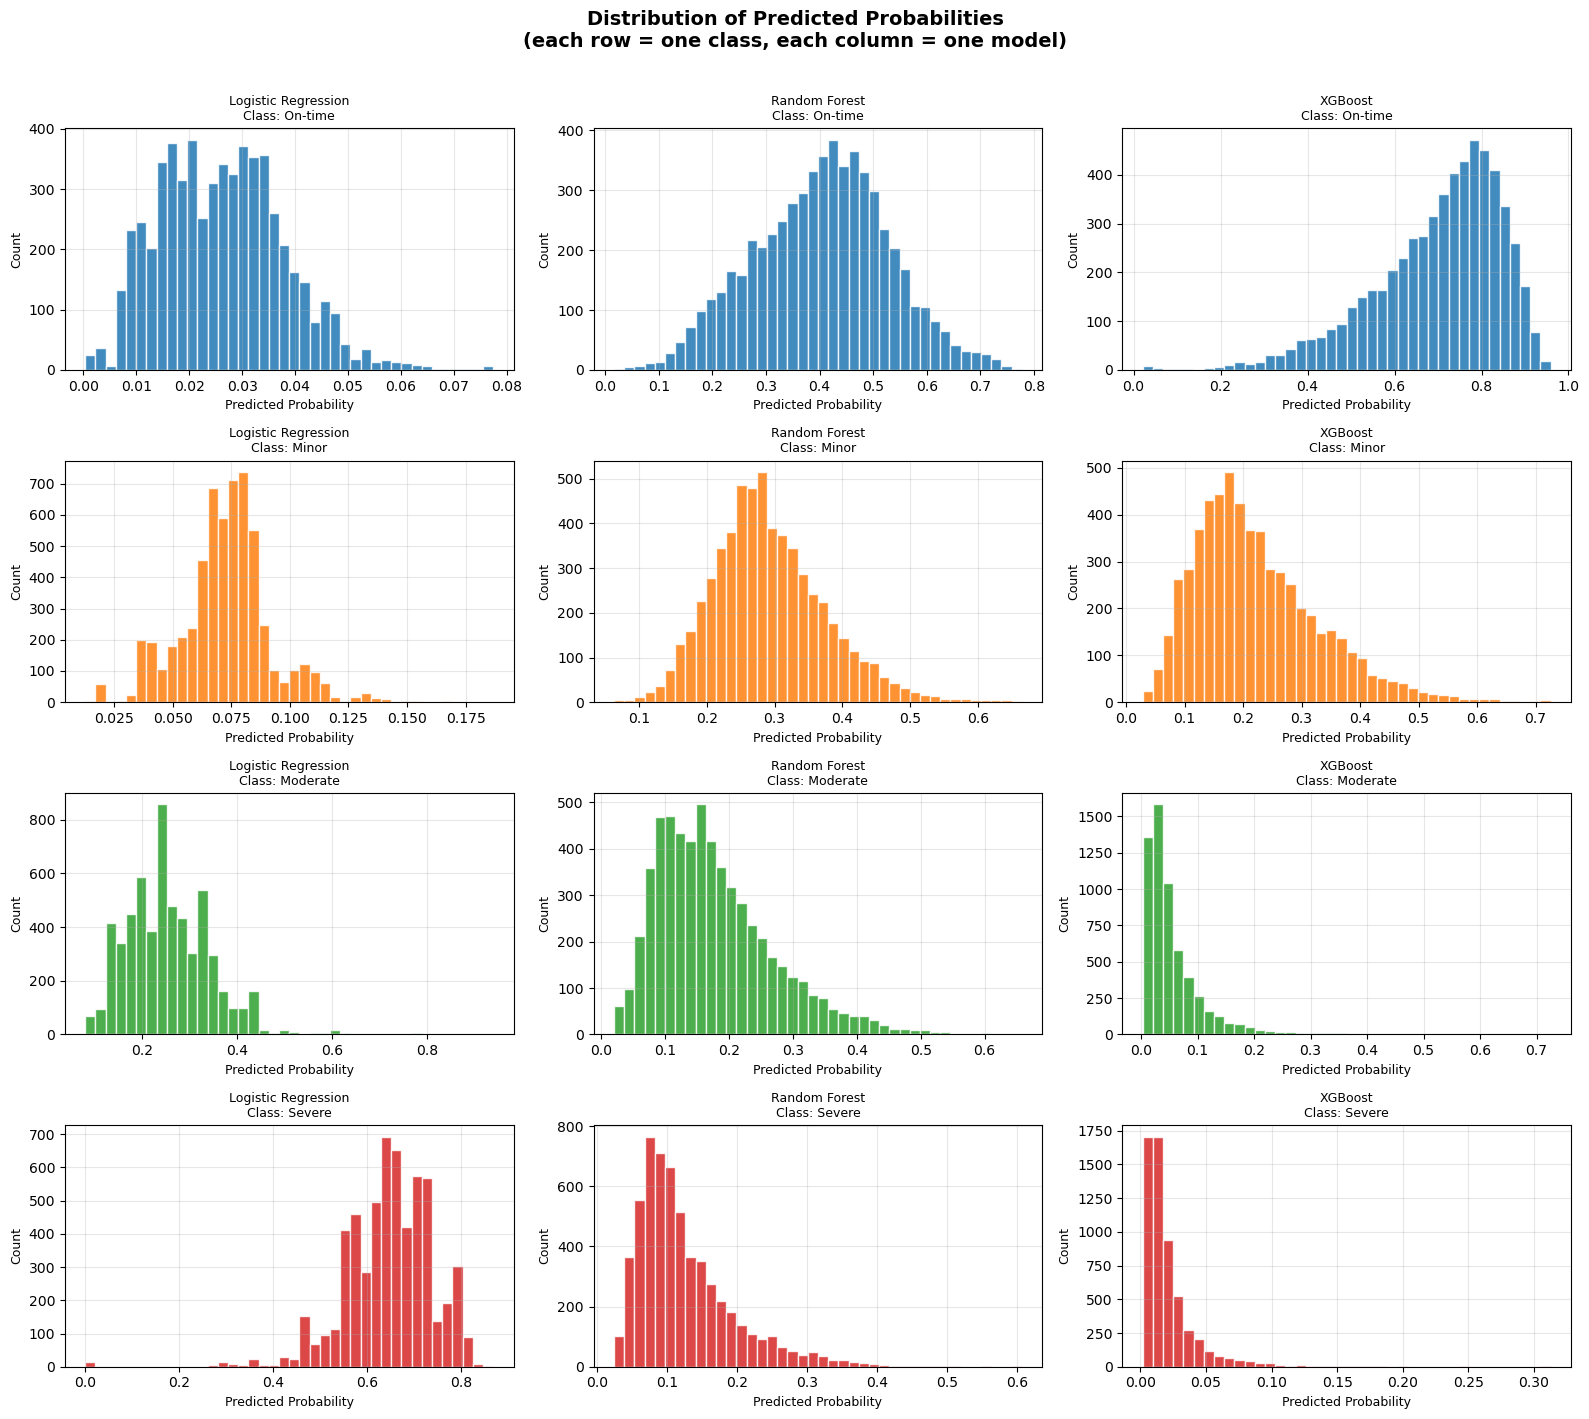

Saved: dist_predicted_probs.png


In [29]:
fig, axes = plt.subplots(n_classes, 3, figsize=(16, 14), sharey=False)
fig.suptitle("Distribution of Predicted Probabilities\n(each row = one class, each column = one model)",
             fontsize=14, fontweight='bold', y=1.01)

for col_idx, (model_name, y_prob) in enumerate(zip(model_names, model_probs)):
    for class_idx, class_name in enumerate(class_names):
        ax = axes[class_idx][col_idx]
        ax.hist(y_prob[:, class_idx], bins=40,
                color=class_colors[class_idx], edgecolor='white', alpha=0.85)
        ax.set_xlabel("Predicted Probability", fontsize=9)
        ax.set_ylabel("Count", fontsize=9)
        ax.set_title(f"{model_name}\nClass: {class_name}", fontsize=9)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dist_predicted_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dist_predicted_probs.png")

#### 2. Precision-Recall Tradeoff (1 plot per model, weighted-averaged)

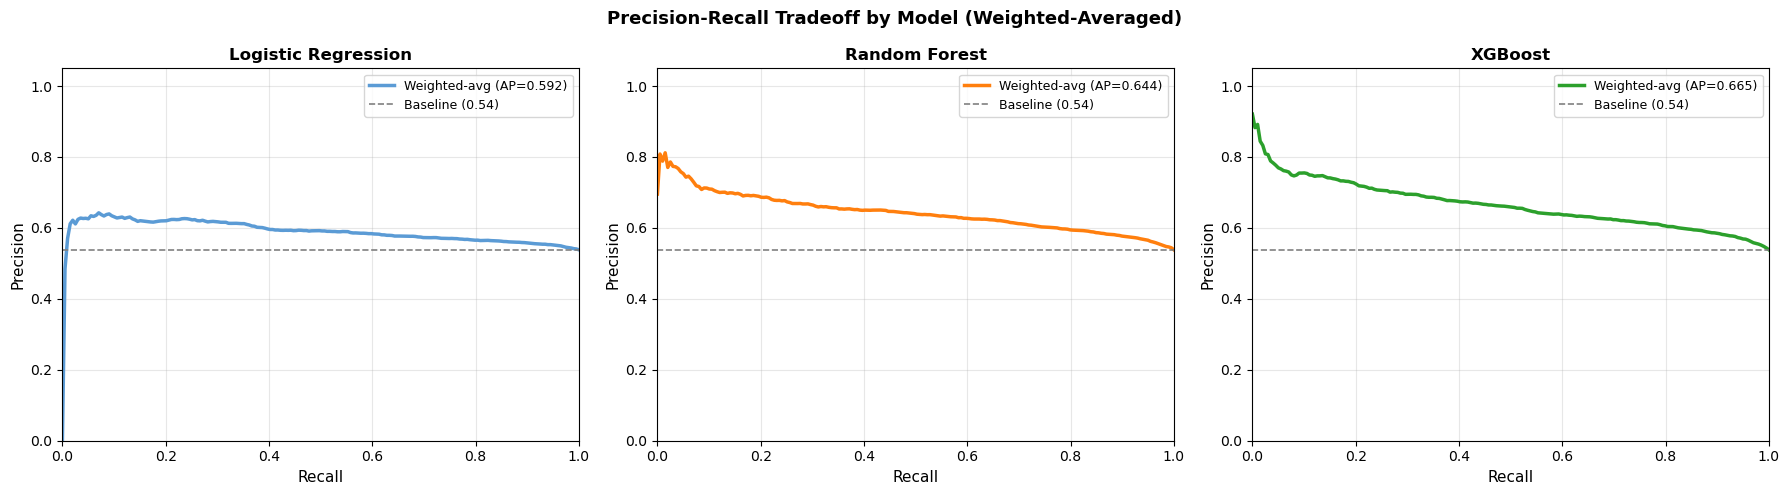

Saved: precision_recall_tradeoff.png


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Precision-Recall Tradeoff by Model (Weighted-Averaged)",
             fontsize=13, fontweight='bold')

# Class weights = proportion of samples in each class
class_weights = np.array([(y_test == c).sum() for c in range(n_classes)]) / len(y_test)

for m_idx, (model_name, y_prob) in enumerate(zip(model_names, model_probs)):
    ax = axes[m_idx]
    mean_rec = np.linspace(0, 1, 200)
    all_prec = []
    for class_idx in range(n_classes):
        prec, rec, _ = precision_recall_curve(
            y_test_bin[:, class_idx], y_prob[:, class_idx]
        )
        all_prec.append(np.interp(mean_rec, rec[::-1], prec[::-1]))
    # Weighted average across classes
    weighted_prec = np.average(all_prec, axis=0, weights=class_weights)
    weighted_ap = average_precision_score(y_test_bin, y_prob, average='weighted')
    baseline = np.sum(class_weights ** 2)  # weighted baseline
    ax.plot(mean_rec, weighted_prec,
            color=model_colors[m_idx], linewidth=2.5,
            label=f'Weighted-avg (AP={weighted_ap:.3f})')
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.2,
               label=f'Baseline ({baseline:.2f})')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('precision_recall_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precision_recall_tradeoff.png')

#### 3. ROC Curve (1 plot per model, weighted-averaged)

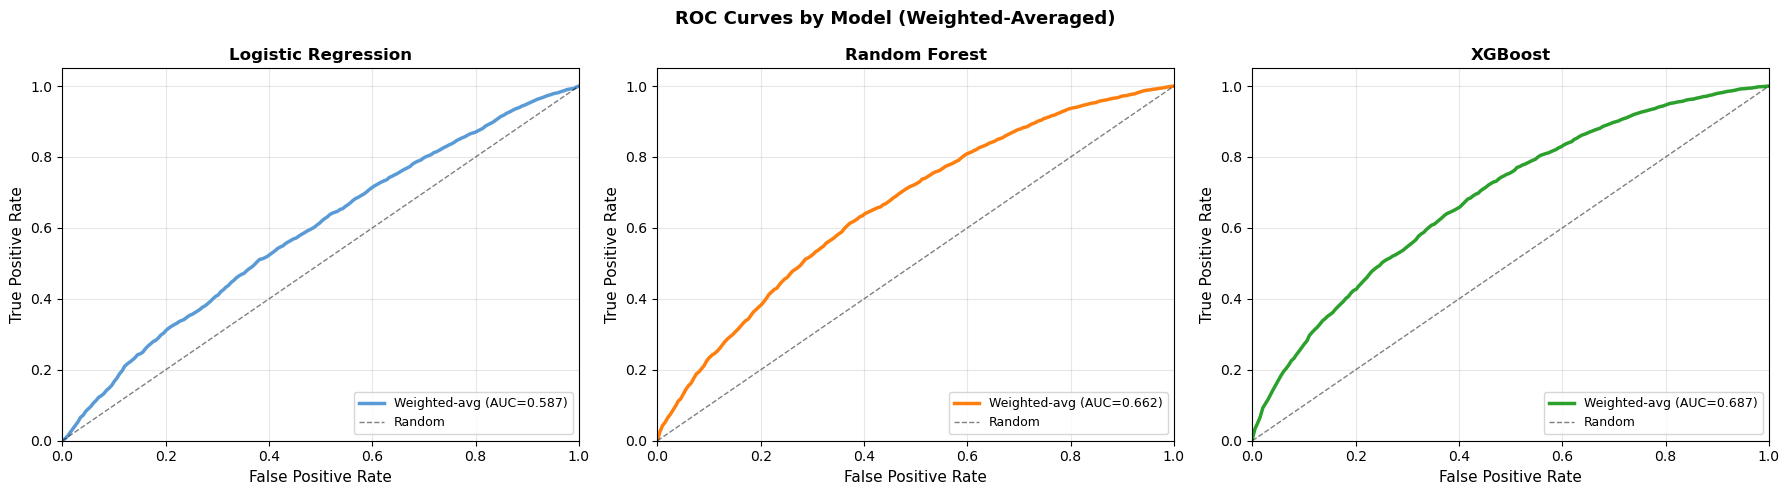

Saved: roc_curves.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ROC Curves by Model (Weighted-Averaged)",
             fontsize=13, fontweight='bold')

for m_idx, (model_name, y_prob) in enumerate(zip(model_names, model_probs)):
    ax = axes[m_idx]
    mean_fpr = np.linspace(0, 1, 200)
    all_tpr = []
    for class_idx in range(n_classes):
        fpr, tpr, _ = roc_curve(
            y_test_bin[:, class_idx], y_prob[:, class_idx]
        )
        all_tpr.append(np.interp(mean_fpr, fpr, tpr))
    # Weighted average across classes
    weighted_tpr = np.average(all_tpr, axis=0, weights=class_weights)
    weighted_auc = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')
    ax.plot(mean_fpr, weighted_tpr,
            color=model_colors[m_idx], linewidth=2.5,
            label=f'Weighted-avg (AUC={weighted_auc:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curves.png')

#### 4. Precision-Recall Curve: MDT Flight Delay Model (1 plot per model, weighted-averaged)

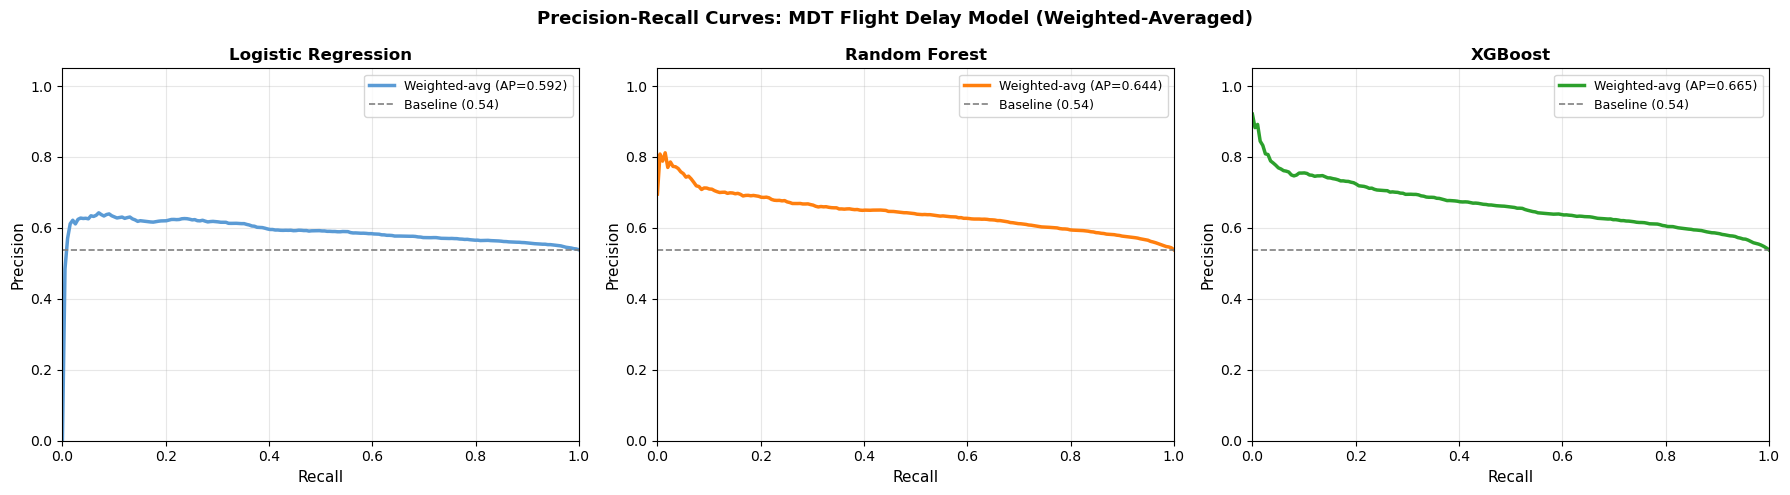

Saved: precision_recall_curve_mdt.png


In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Precision-Recall Curves: MDT Flight Delay Model (Weighted-Averaged)",
             fontsize=13, fontweight='bold')

for m_idx, (model_name, y_prob) in enumerate(zip(model_names, model_probs)):
    ax = axes[m_idx]
    mean_rec = np.linspace(0, 1, 200)
    all_prec = []
    for class_idx in range(n_classes):
        prec, rec, _ = precision_recall_curve(
            y_test_bin[:, class_idx], y_prob[:, class_idx]
        )
        all_prec.append(np.interp(mean_rec, rec[::-1], prec[::-1]))
    weighted_prec = np.average(all_prec, axis=0, weights=class_weights)
    weighted_ap = average_precision_score(y_test_bin, y_prob, average='weighted')
    baseline = np.sum(class_weights ** 2)
    ax.plot(mean_rec, weighted_prec,
            color=model_colors[m_idx], linewidth=2.5,
            label=f'Weighted-avg (AP={weighted_ap:.3f})')
    ax.axhline(baseline, color='gray', linestyle='--', linewidth=1.2,
               label=f'Baseline ({baseline:.2f})')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('precision_recall_curve_mdt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: precision_recall_curve_mdt.png')

#### 5. Summary: Weighted ROC-AUC and Average Precision per model

                     Weighted ROC-AUC  Weighted Avg Precision (AP)
Model                                                             
Logistic Regression            0.5872                       0.5918
Random Forest                  0.6615                       0.6439
XGBoost                        0.6869                       0.6648


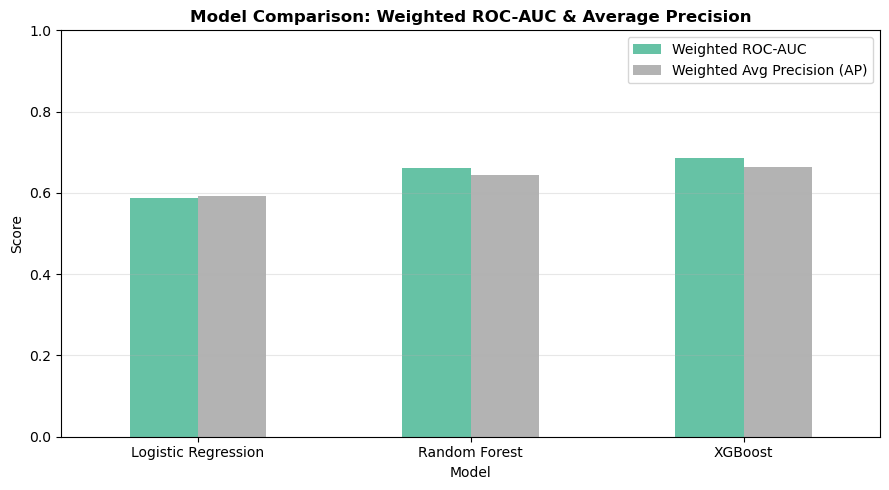

Saved: model_summary_roc_ap.png


In [35]:
from sklearn.metrics import roc_auc_score

summary_rows = []
for model_name, y_prob in zip(model_names, model_probs):
    weighted_roc = roc_auc_score(y_test_bin, y_prob, average='weighted', multi_class='ovr')
    weighted_ap  = average_precision_score(y_test_bin, y_prob, average='weighted')
    summary_rows.append({
        'Model': model_name,
        'Weighted ROC-AUC': round(weighted_roc, 4),
        'Weighted Avg Precision (AP)': round(weighted_ap, 4),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print(summary_df)

summary_df.plot(kind='bar', figsize=(9, 5), colormap='Set2')
plt.title('Model Comparison: Weighted ROC-AUC & Average Precision',
          fontsize=12, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_summary_roc_ap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_summary_roc_ap.png')